<a href="https://colab.research.google.com/github/yasminemasmoudi/NLP/blob/master/Email_Spam_Classfication_using_LSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
%cd drive/

/content/drive


In [ ]:
df=pd.read_csv('MyDrive/Data/Spam_data/spam.csv',encoding="ISO-8859-1")

In [ ]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4957,ham,Why didn't u call on your lunch?,NaN,NaN,NaN
3722,ham,We left already we at orchard now.,NaN,NaN,NaN
2037,ham,Oh sorry please its over,NaN,NaN,NaN
4051,ham,"Ya ok, then had dinner?",NaN,NaN,NaN
370,ham,Hello my boytoy ... Geeee I miss you already a...,NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

### **1. Data cleaning**
### **2. EDA(Exploratory Data analysis)**
### **3. Text Preprocessing**
### **4. Model building**
### **5. Evaluation**

#**1/data_cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [ ]:
# renaming columns
df.rename(columns={'v1':'spam','v2':'text'},inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['spam'] = encoder.fit_transform(df['spam'])

In [ ]:
df.head()

,spam,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# missing values
df.isnull().sum()

spam    0
text    0
dtype: int64

In [ ]:
df['spam'].value_counts()

0    4825
1     747
Name: spam, dtype: int64

In [ ]:
# check for duplicate values
#df.duplicated()
df.duplicated().sum()

403

In [ ]:
# remove duplicates
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

0

In [ ]:
df.shape

(5169, 2)

#**2/EDA**

In [ ]:
df.head()

,spam,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['spam'].value_counts()

0    4516
1     653
Name: spam, dtype: int64

<AxesSubplot:>

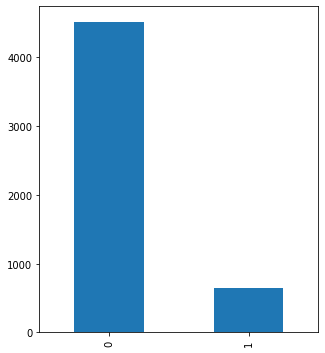

In [ ]:
df['spam'].value_counts().head(32).plot( kind='bar',figsize=(5,6))

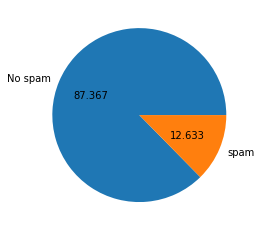

In [ ]:
plt.pie(df['spam'].value_counts(), labels=['No spam','spam'],autopct="%0.3f")
plt.show()

In [ ]:
!pip install nltk

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import nltk

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
#number of characters
df['num_characters'] = df['text'].apply(len)
# number of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
#number of sentences
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,spam,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.453279,1.947185
std,58.236293,13.324793,1.362406
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,28.000000


In [ ]:
#no spam
df[df['spam'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.120903,1.799601
std,56.358207,13.493725,1.278465
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,28.000000


In [ ]:
#spam
df[df['spam'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.967841
std,30.137753,7.008418,1.483201
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,8.000000


<AxesSubplot:xlabel='num_characters', ylabel='Count'>

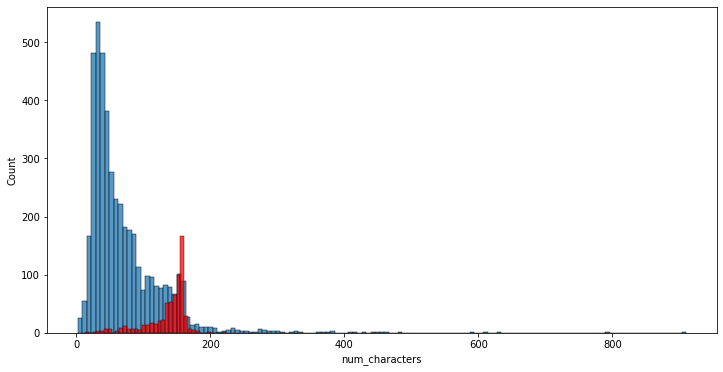

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['spam'] == 0]['num_characters'])
sns.histplot(df[df['spam'] == 1]['num_characters'],color='red')

<AxesSubplot:xlabel='num_words', ylabel='Count'>

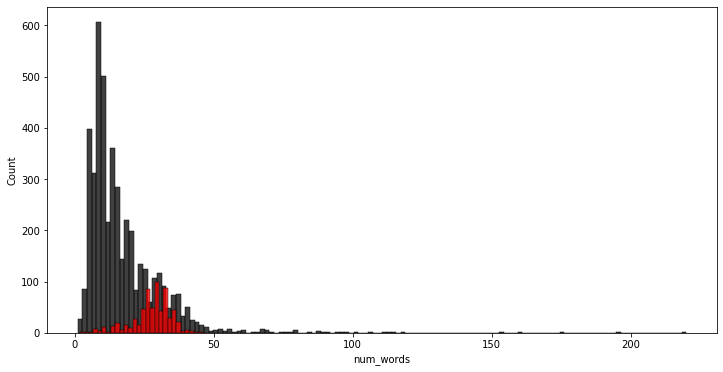

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['spam'] == 0]['num_words'],color='black')
sns.histplot(df[df['spam'] == 1]['num_words'],color='red')

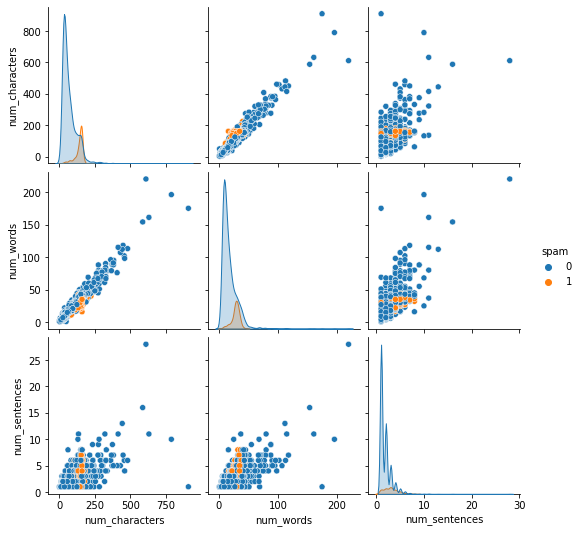

In [ ]:
sns.pairplot(df,hue='spam')

<AxesSubplot:>

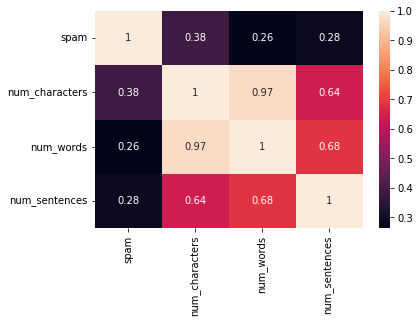

In [ ]:
sns.heatmap(df.corr(),annot=True)

#**3/Data Preprocessing**
1. Lower case
2. Tokenization
3. Removing special characters
4. Removing stop words and punctuation
5. Stemming










In [ ]:
from nltk.corpus import stopwords
nltk.download("stopwords")
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
import string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation :
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [ ]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [ ]:
transform_text(df['text'][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [ ]:
ps.stem('doing')

'do'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,spam,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [ ]:
spam_wc = wc.generate(df[df['spam'] == 1]['transformed_text'].str.cat(sep=" "))

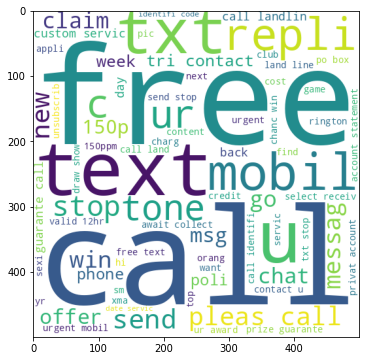

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

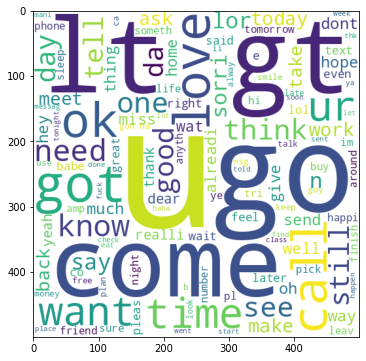

In [ ]:
no_spam = wc.generate(df[df['spam'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(no_spam)

In [ ]:
spam_corpus = []
for msg in df[df['spam'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [ ]:
len(spam_corpus)

9939

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


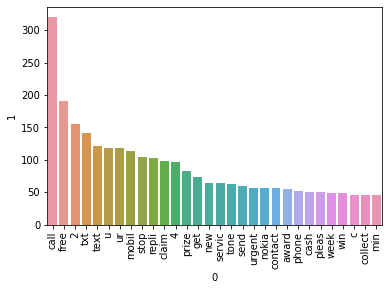

In [ ]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0],pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus = []
for msg in df[df['spam'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [ ]:
len(ham_corpus)

35394

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


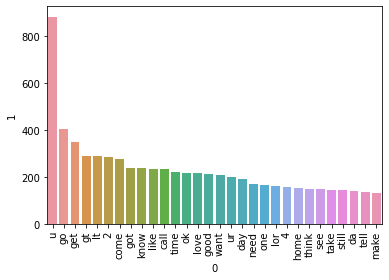

In [ ]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[0],pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

#**4/ Model Building**


In [ ]:
from sklearn.model_selection import train_test_split
from keras.preprocessing.text import Tokenizer
from keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.layers import Dense, LSTM, Embedding

In [ ]:
#Separate train- and test-data
df_train = df.sample(frac=.8, random_state=11)
df_test = df.drop(df_train.index)
print(df_train.shape, df_test.shape)

(4135, 6) (1034, 6)


In [ ]:
df.head()

,spam,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
#Create y-data for analysis
y_train = df_train['spam'].values
y_test = df_test['spam'].values
y_test.shape

(1034,)

In [ ]:
#Create x-data for analysis
X_train = df_train['text'].values
X_test = df_test['text'].values

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
word_dict = tokenizer.index_word
#print(len(word_dict))
#print(word_dict)

#for key in word_dict.keys():
#    print(key, word_dict[key])

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
print(X_train_seq[:5])
print(df_train.iloc[0,:])
for el in X_train_seq[0]:
    print(word_dict[el], end=' ')

[[25, 234, 142, 190, 3470, 2357, 3471, 3472, 3473, 3474, 612, 1867, 7, 3475, 1027, 3476], [143, 22, 66, 469, 13, 165], [444, 37, 256, 30, 256, 25, 49, 3, 1028, 3, 162, 652, 23, 3477, 3478, 3479, 8, 17], [368, 3480, 1029, 369], [85, 34, 40, 1155, 43, 2358, 3481, 506, 1322, 3482, 1323, 1324, 58, 51, 50, 203, 109, 208, 22, 20, 881, 62, 3483, 3484, 1325, 1868]]
spam                                                                0
text                Not yet had..ya sapna aunty manege y'day hogid...
num_characters                                                     94
num_words                                                          19
num_sentences                                                       1
transformed_text    yet ya sapna aunti maneg hogidh chinnu full we...
Name: 2964, dtype: object
not yet had ya sapna aunty manege y'day hogidhe chinnu full weak and swalpa black agidhane 

In [ ]:
#Create pads with fix length
#Maximul length 20
X_train_pad = pad_sequences(X_train_seq, maxlen=20, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=20, padding='post')
X_train_pad[:5]
X_train_pad.shape

(4135, 20)

#**CreateKeras-model**
"Long Short Term Memory" (LSTM) is used

In [ ]:
laenge_pads = 20
anz_woerter = 7982

lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=anz_woerter+1, output_dim=20, input_length=laenge_pads))
lstm_model.add(LSTM(400))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 20, 20)            159660    
                                                                 
 lstm (LSTM)                 (None, 400)               673600    
                                                                 
 dense (Dense)               (None, 1)                 401       
                                                                 
Total params: 833,661
Trainable params: 833,661
Non-trainable params: 0
_________________________________________________________________


In [ ]:
#train model
history = lstm_model.fit(X_train_pad, y_train, epochs=50, batch_size=64, 
                        validation_data=(X_test_pad, y_test))

Epoch 1/50
65/65 [==============================] - 20s 189ms/step - loss: 0.2100 - accuracy: 0.9212 - val_loss: 0.0937 - val_accuracy: 0.9700
Epoch 2/50
65/65 [==============================] - 6s 95ms/step - loss: 0.0386 - accuracy: 0.9865 - val_loss: 0.0693 - val_accuracy: 0.9797
Epoch 3/50
65/65 [==============================] - 3s 45ms/step - loss: 0.0164 - accuracy: 0.9949 - val_loss: 0.1040 - val_accuracy: 0.9758
Epoch 4/50
65/65 [==============================] - 3s 54ms/step - loss: 0.0021 - accuracy: 0.9990 - val_loss: 0.1258 - val_accuracy: 0.9778
Epoch 5/50
65/65 [==============================] - 3s 39ms/step - loss: 0.0044 - accuracy: 0.9988 - val_loss: 0.0871 - val_accuracy: 0.9758
Epoch 6/50
65/65 [==============================] - 2s 32ms/step - loss: 0.0128 - accuracy: 0.9983 - val_loss: 0.1318 - val_accuracy: 0.9739
Epoch 7/50
65/65 [==============================] - 1s 16ms/step - loss: 3.2474e-04 - accuracy: 1.0000 - val_loss: 0.2735 - val_accuracy: 0.9691
Epoch 8

#**5/ Test-Estimation**

In [ ]:
sms_test = ['Free SMS service for anyone']
sms_seq = tokenizer.texts_to_sequences(sms_test)

sms_pad = pad_sequences(sms_seq, maxlen=20, padding='post')
tokenizer.index_word
sms_pad
(lstm_model.predict(sms_pad)>0.5).astype("int32")

1/1 [==============================] - 1s 1s/step


array([[1]], dtype=int32)

Donc SPAM


In [ ]:
sms_test = ['Hi Paul, would you come around tonight']
sms_seq = tokenizer.texts_to_sequences(sms_test)

sms_pad = pad_sequences(sms_seq, maxlen=20, padding='post')
tokenizer.index_word
sms_pad
(lstm_model.predict(sms_pad)>0.5).astype("int32")

1/1 [==============================] - 0s 35ms/step


array([[0]], dtype=int32)

NO SPAM